In [1]:
import json
import seaborn as sns
import os

from src.visualization import aggregate_empirical_results, plot_histograms, topic_area_per_project, visualize_policy_population, animate_knowledge_space
# Set seaborn theme globally
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)

## 1. Aggregate Empirical Results (RL vs Heuristics)


### "multiply"

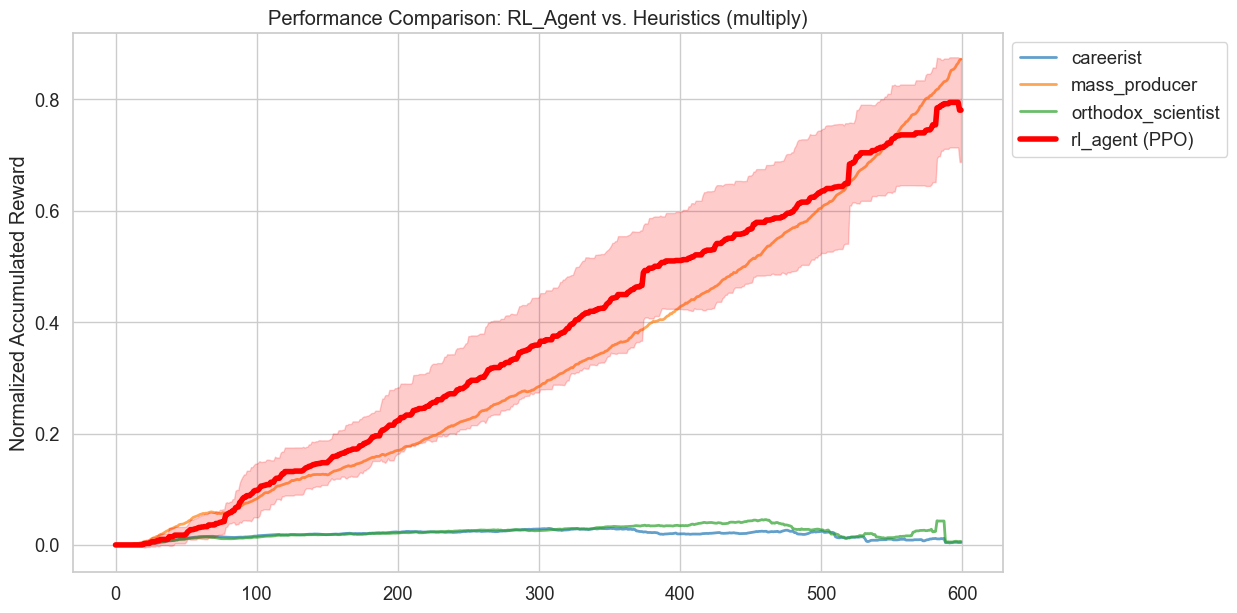

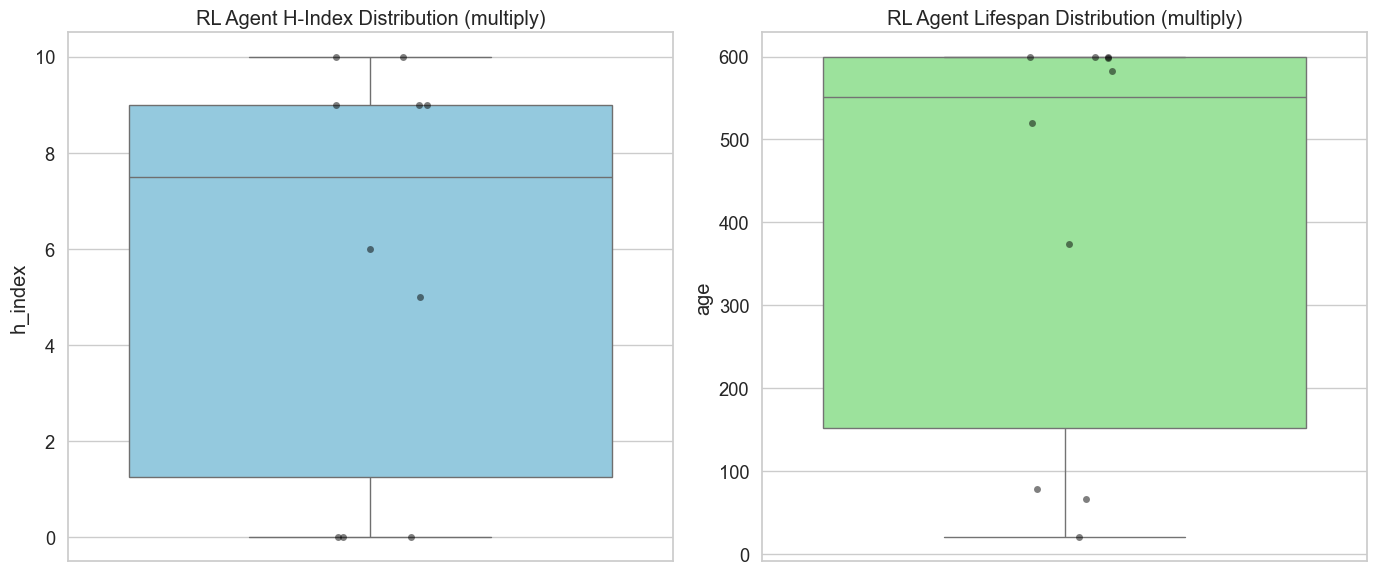


--- Final Mean Reward (Step 599) for multiply ---
RL_Agent: 30.11
careerist         : 0.16
mass_producer     : 33.64
orthodox_scientist: 0.24

RL Agent is -10.5% better than the best heuristic (mass_producer).


In [2]:
aggregate_empirical_results("multiply")



### "by_effort"

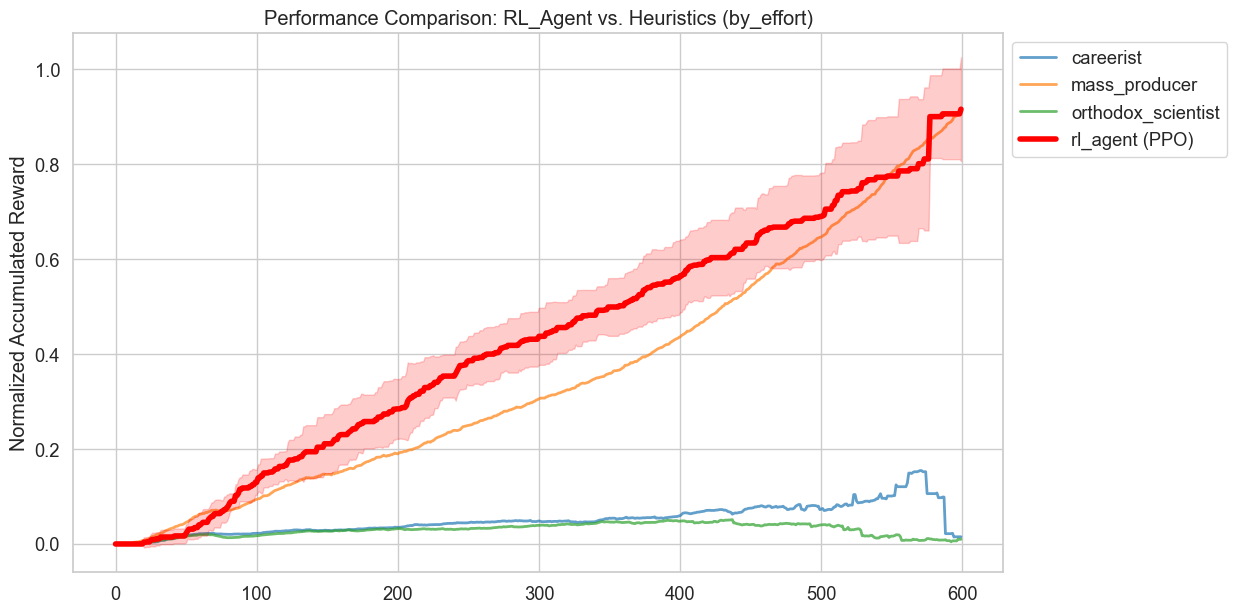

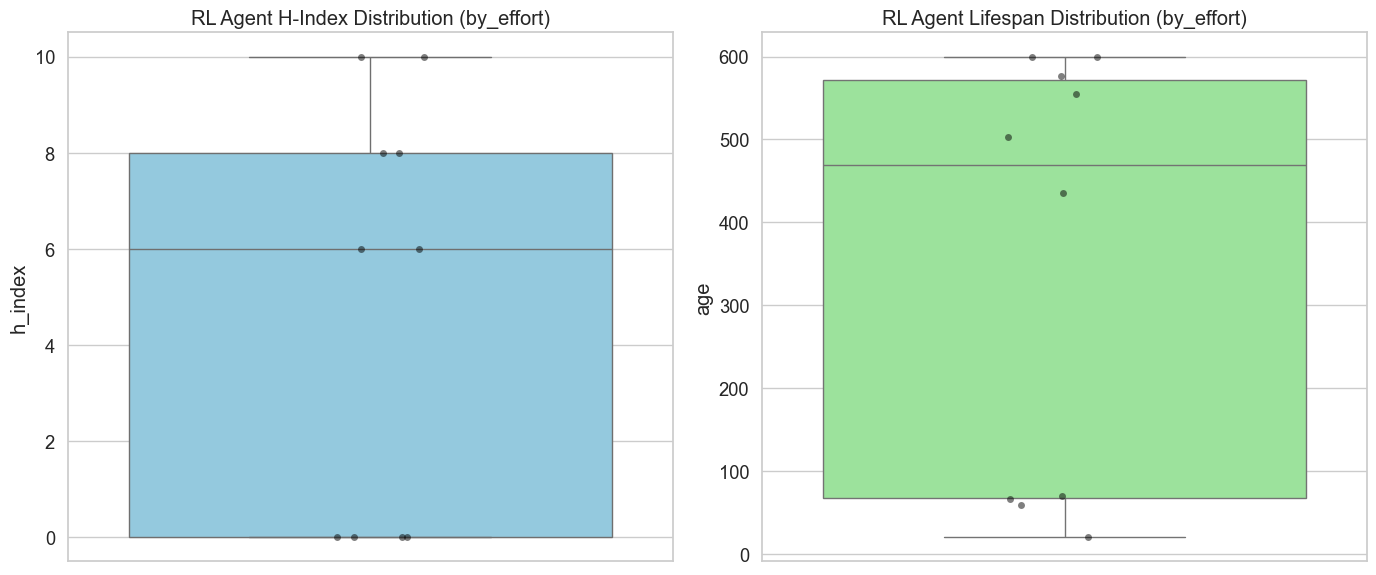


--- Final Mean Reward (Step 599) for by_effort ---
RL_Agent: 21.47
careerist         : 0.35
mass_producer     : 21.35
orthodox_scientist: 0.23

RL Agent is +0.6% better than the best heuristic (mass_producer).


In [3]:
aggregate_empirical_results("by_effort")

### "evenly"

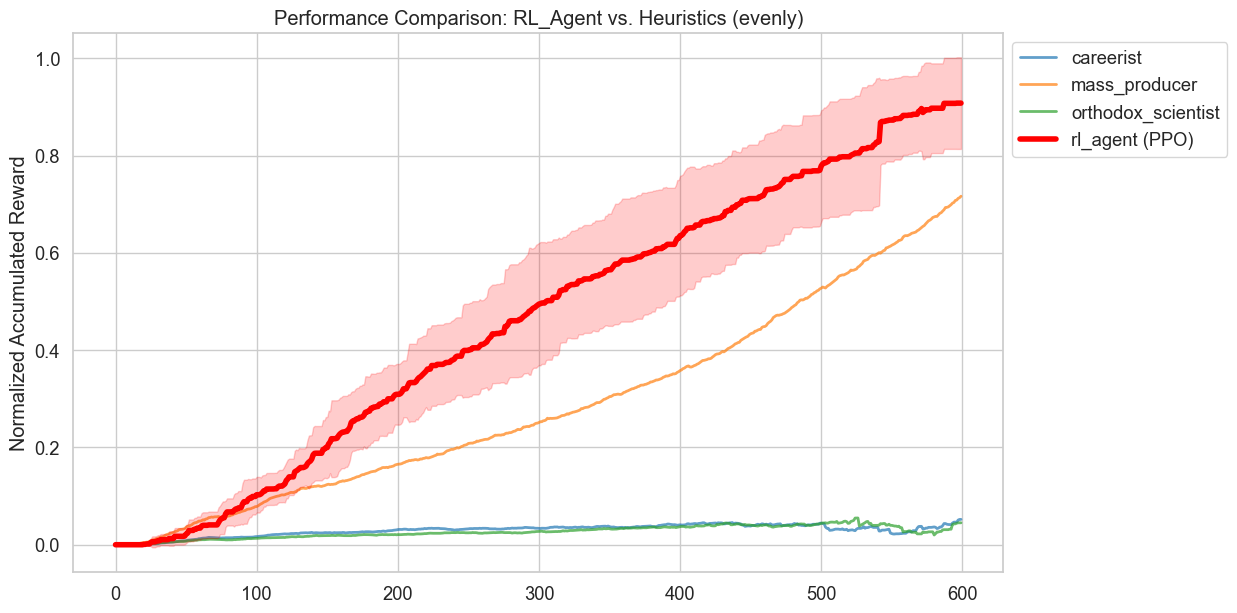

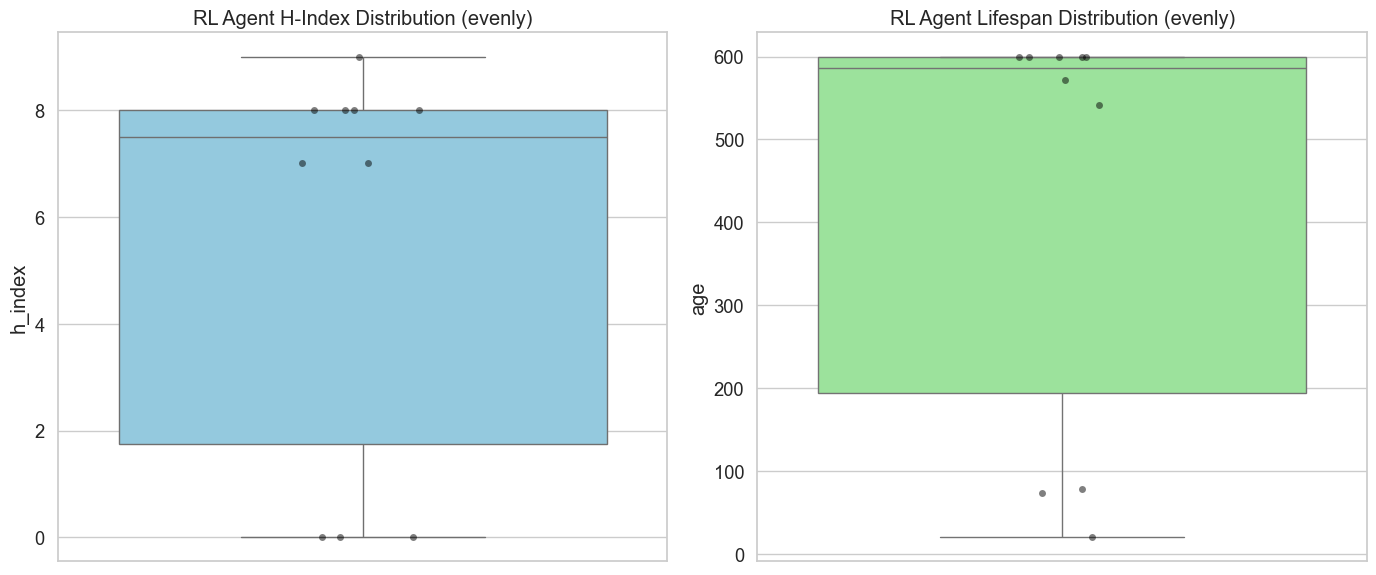


--- Final Mean Reward (Step 599) for evenly ---
RL_Agent: 20.22
careerist         : 1.16
mass_producer     : 15.96
orthodox_scientist: 1.00

RL Agent is +26.7% better than the best heuristic (mass_producer).


In [4]:
aggregate_empirical_results("evenly")

## 2. Detailed Simulation Analysis (Single Seed)
This section performs a deep dive into one specific RL simulation run.


Loaded detailed logs for Seed 110 (by_effort)


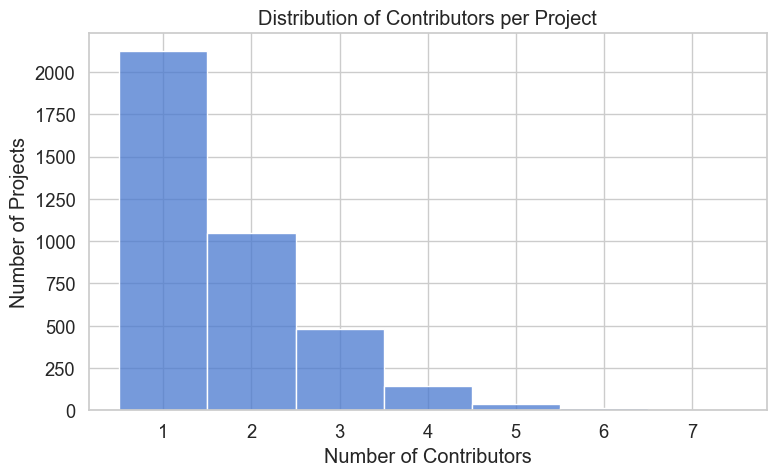

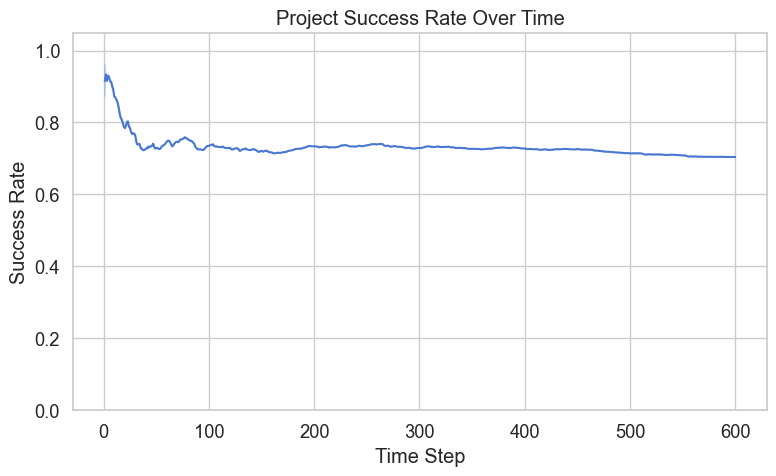

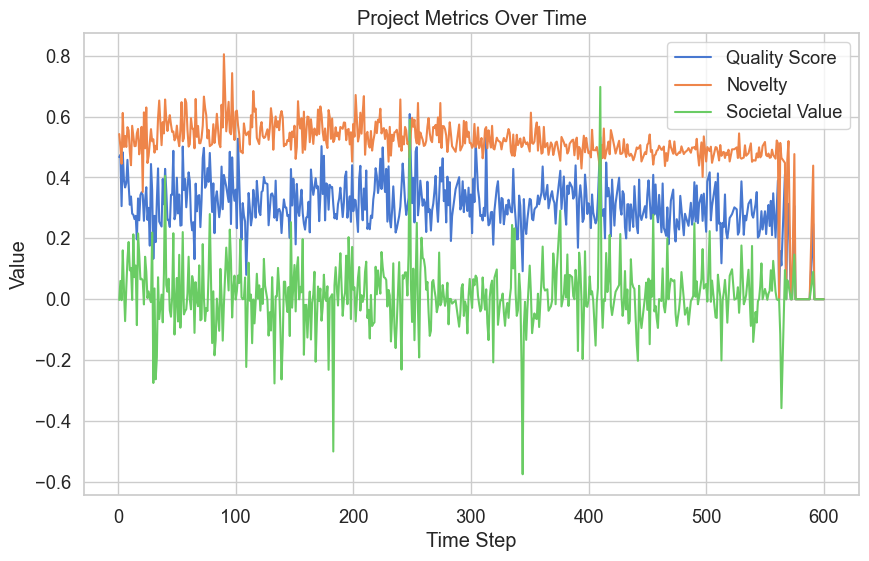

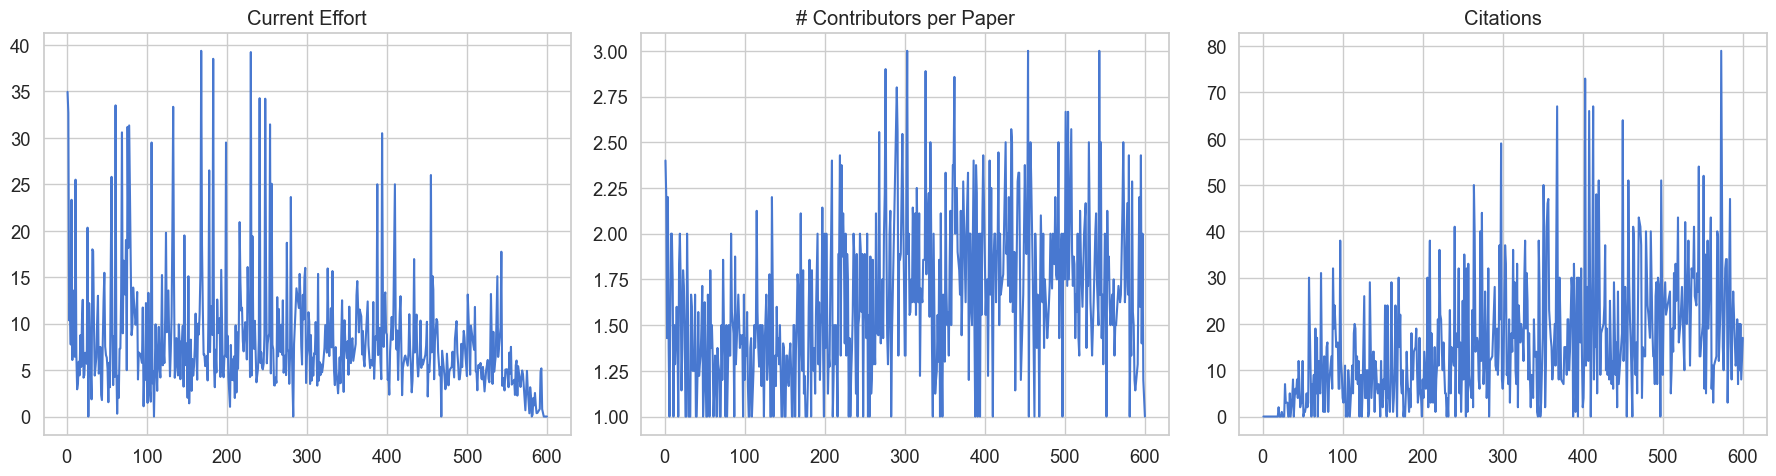

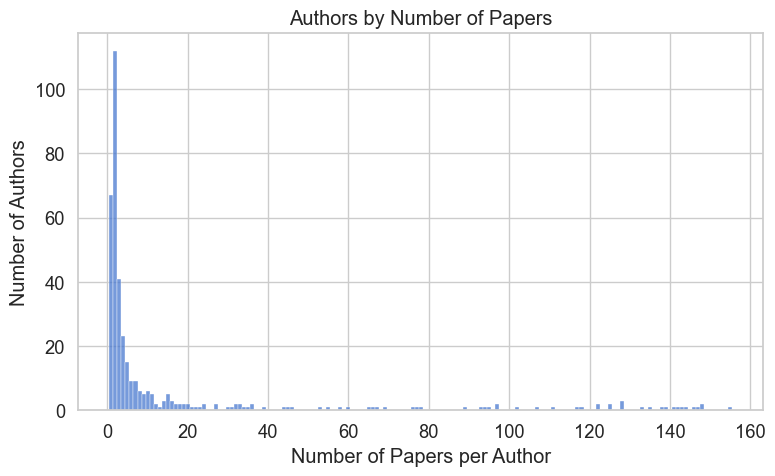

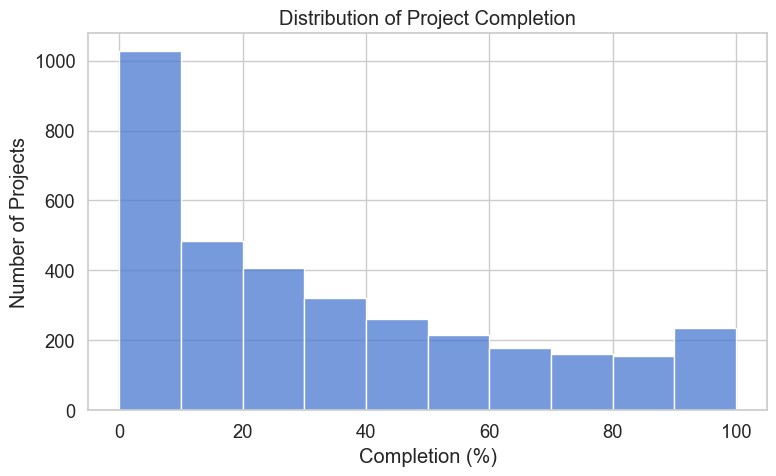

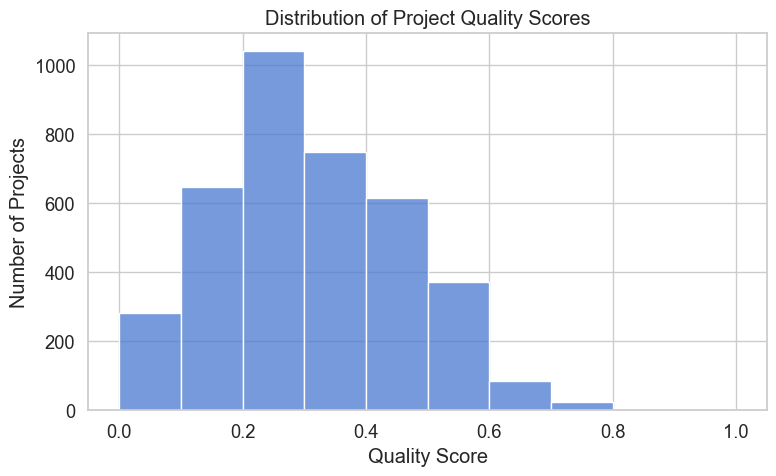

Loaded observations for RL Agent trajectory.


TypeError: topic_area_per_project() got an unexpected keyword argument 'observations'

In [8]:
# Configuration for deep dive
SEED = 110
STRAT = "by_effort" # Change this to "multiply" or "evenly" if desired

try:
    proj_file = f"../log/rl_ppo_{STRAT}_s{SEED}_projects.json"
    act_file = f"../log/rl_ppo_{STRAT}_s{SEED}_actions.jsonl"
    area_file = f"../log/rl_ppo_{STRAT}_s{SEED}_area.pickle"

    with open(proj_file, "r") as f:
        projects = json.load(f)
    with open(act_file, "r") as f:
        actions = [json.loads(line) for line in f]
    print(f"Loaded detailed logs for Seed {SEED} ({STRAT})")

    # Run the standard visualization suite
    plot_histograms(projects, actions)

    # Knowledge Space Visualization
    if os.path.exists(area_file):
        # Versuche Observations zu laden, falls vorhanden
        obs_file = f"../log/rl_ppo_{STRAT}_s{SEED}_observations.jsonl"
        observations = None
        if os.path.exists(obs_file):
            with open(obs_file, "r") as f:
                observations = [json.loads(line) for line in f]
            print(f"Loaded observations for RL Agent trajectory.")
            
        topic_area_per_project(projects, actions, area_file, observations=observations)
        
        # NEU: Animation des Knowledge Space
        print("\nCreating Knowledge Space Animation...")
        ani = animate_knowledge_space(projects, actions, area_file, observations=observations)
        # Um die Animation im Notebook anzuzeigen:
        # display(HTML(ani.to_jshtml()))
        # In einer statischen Umgebung speichern wir sie oder geben einen Hinweis
        # ani.save("knowledge_space_evolution.mp4")
        print("Animation created. Use 'HTML(ani.to_jshtml())' to view it in a Jupyter cell.")
    else:
        print(f"Area file not found at {area_file}")
except FileNotFoundError as e:
    print(f"Could not load detailed logs for Seed {SEED} ({STRAT}): {e}")

# %% [markdown]
# ## 2.1 Knowledge Space Animation
# Führe diese Zelle aus, um die Animation der Publikationen über die Zeit zu sehen.

# %%
if 'ani' in locals():
    from IPython.display import HTML
    display(HTML(ani.to_jshtml()))
else:
    print("Animation object 'ani' not found. Please run the Detailed Simulation Analysis cell first.")

# %%
# ### Archetype Proportions Over Time
# Tracks how the population composition (heuristic types + RL agent) changes during the run.

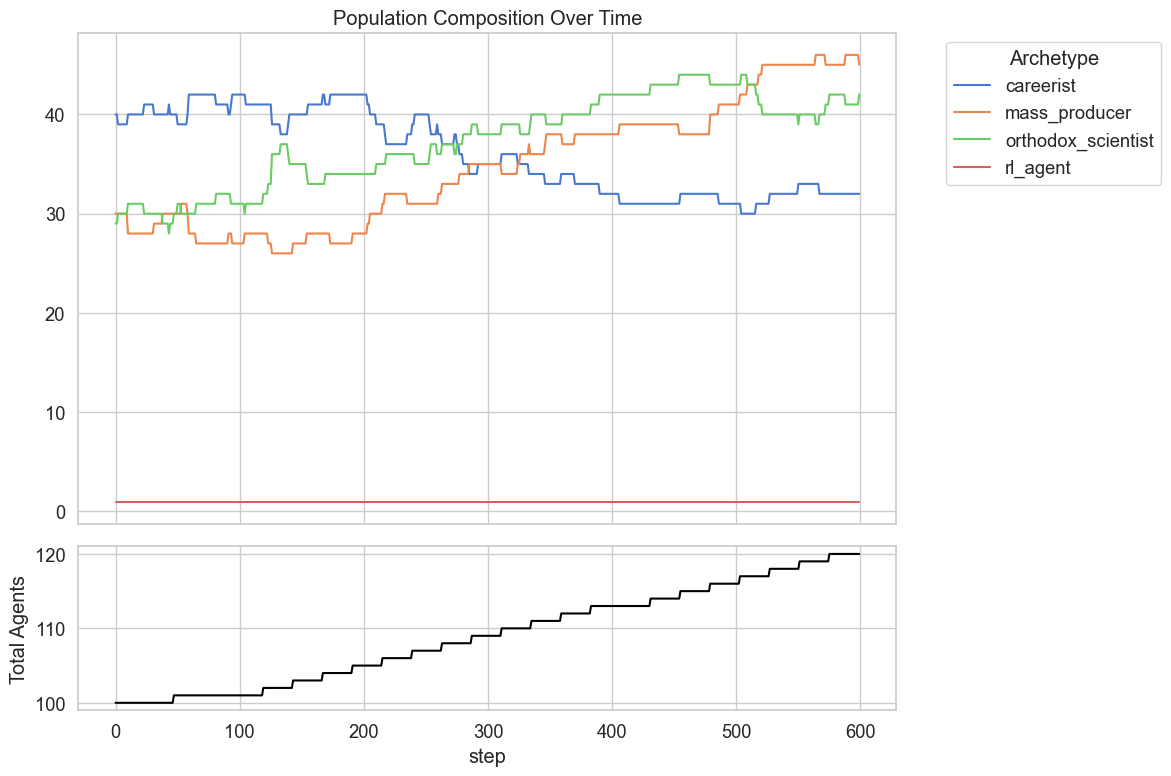

In [7]:
if 'actions' in locals():
    visualize_policy_population(actions)


## 3. Comparison of Reward Functions across ALL Archetypes (including RL Agent)


Processing archetype: careerist ...

Archetype: careerist
conventional vs fractional          | sig. proportion:  0.153 | min p(FDR):  0.00001 | median p(FDR):  0.94827 | valid tests: 588/600
conventional vs by effort           | sig. proportion:  0.000 | min p(FDR):  0.86390 | median p(FDR):  0.86390 | valid tests: 588/600
fractional vs by effort             | sig. proportion:  0.078 | min p(FDR):  0.00035 | median p(FDR):  0.24993 | valid tests: 588/600

Processing archetype: orthodox_scientist ...

Archetype: orthodox_scientist
conventional vs fractional          | sig. proportion:  0.975 | min p(FDR):  0.00000 | median p(FDR):  0.00000 | valid tests: 593/600
conventional vs by effort           | sig. proportion:  0.000 | min p(FDR):  0.93950 | median p(FDR):  0.93950 | valid tests: 593/600
fractional vs by effort             | sig. proportion:  0.975 | min p(FDR):  0.00000 | median p(FDR):  0.00000 | valid tests: 593/600

Processing archetype: mass_producer ...

Archetype: mass_pr

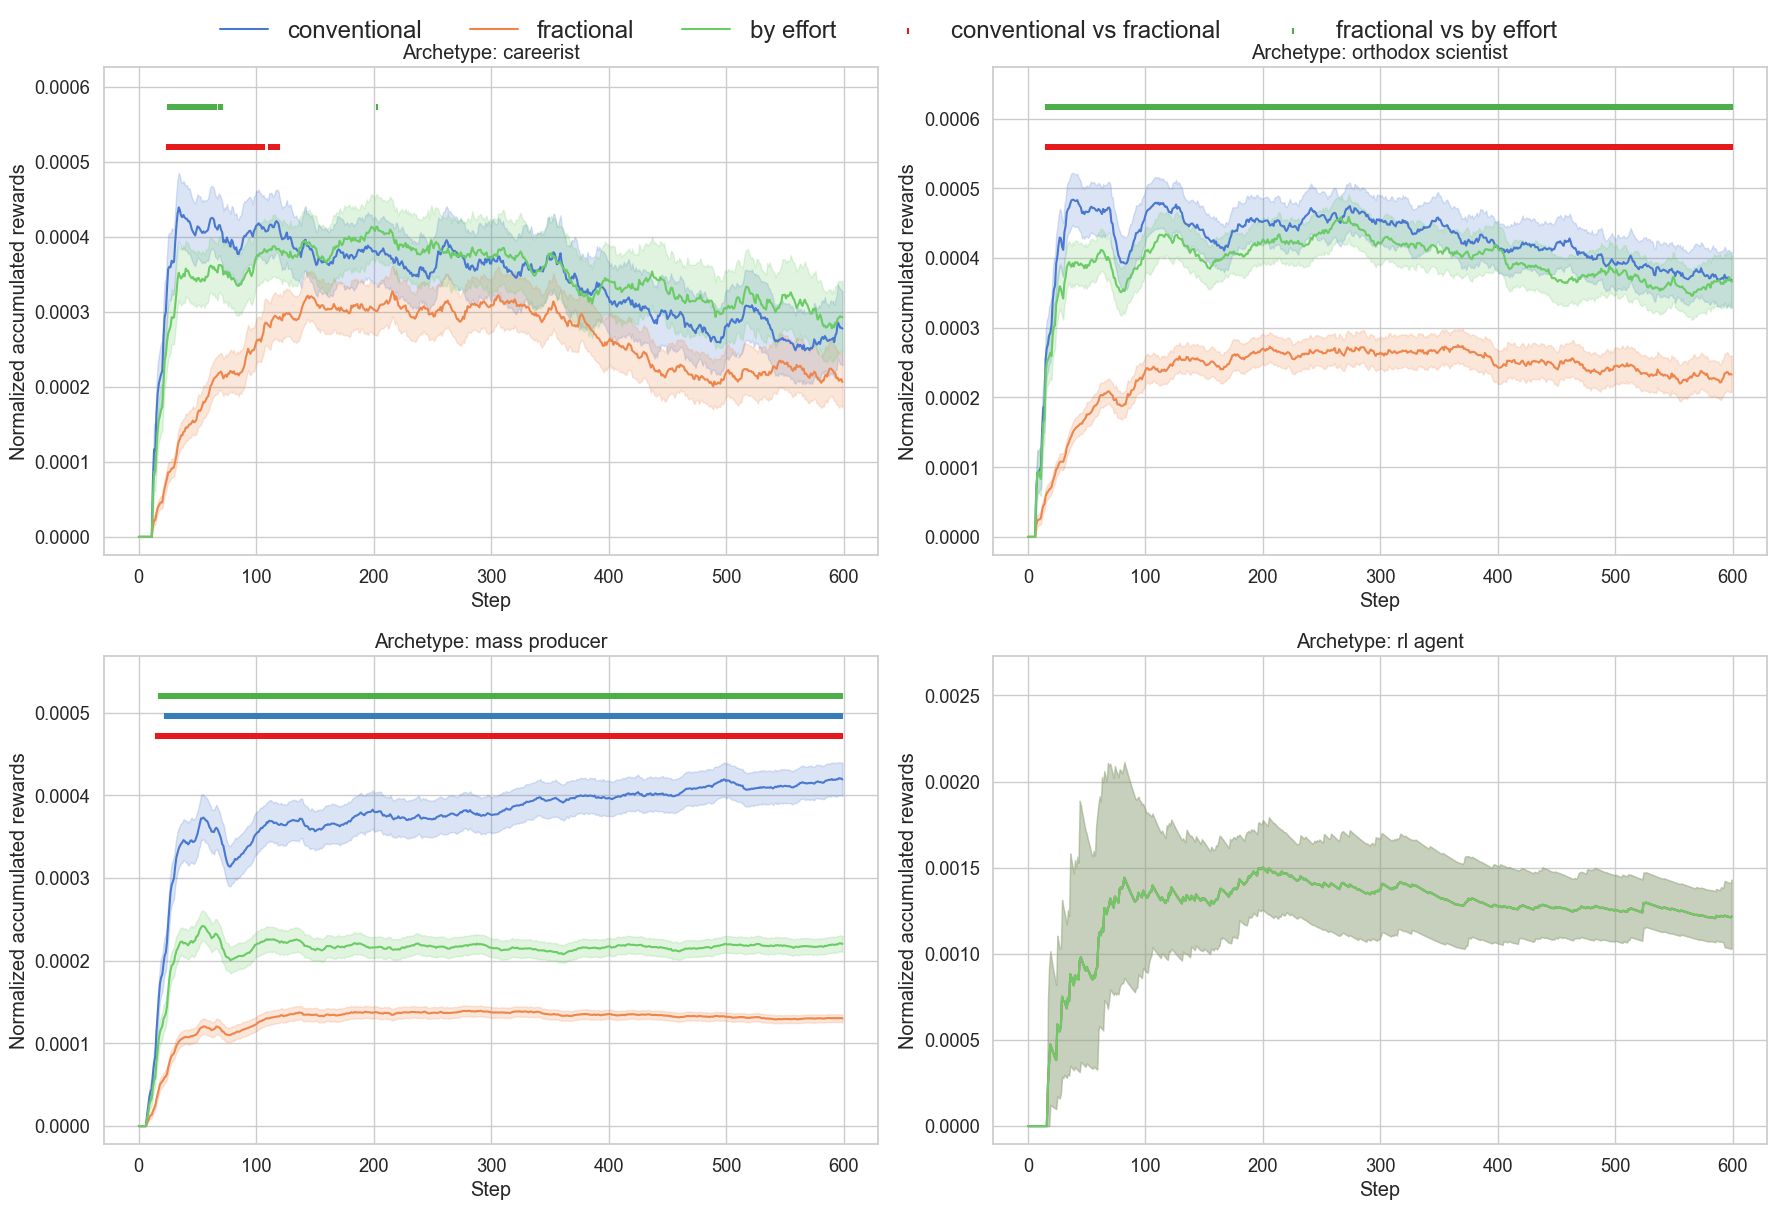

In [7]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# =========================================================
# CONFIG
# =========================================================

variants = {
    "multiply": "conventional",
    "even": "fractional",
    "by_effort": "by effort"
}

archetypes = [
    "careerist",
    "orthodox_scientist",
    "mass_producer",
    "rl_agent"
]

time_steps = list(range(600))
pairs = list(combinations(variants.keys(), 2))
pair_colors = ['#e41a1c', '#377eb8', '#4daf4a']  # red, blue, green

USE_AGE_NORMALIZATION = True
ALPHA = 0.05
FDR_METHOD = "fdr_bh"
N_BOOT = 2000
CI_MODE = "ci"   # or "se"


# =========================================================
# LOAD DATA
# =========================================================

dfs = {}

for v in variants:
    heuristic_path = f"results/reward_trajectories_{v if v != 'even' else 'evenly'}.parquet"
    rl_path = f"results/rl_trajectories_{v if v != 'even' else 'evenly'}.parquet"

    # Heuristic data
    df_h = pd.read_parquet(heuristic_path)

    # RL data: only keep rl_agent rows
    df_rl_all = pd.read_parquet(rl_path)
    df_rl_agent = df_rl_all[df_rl_all["archetype"] == "rl_agent"].copy()

    # Combine
    dfs[v] = pd.concat([df_h, df_rl_agent], ignore_index=True)


# =========================================================
# HELPER FUNCTIONS
# =========================================================

def get_archetype_global_max(dfs_dict, arch, reward_col="accumulated_rewards"):
    """
    Compute one common max reward for a given archetype across all variants.
    This avoids each variant being normalized by its own max.
    """
    maxima = []

    for v in dfs_dict:
        subset = dfs_dict[v].loc[dfs_dict[v]["archetype"] == arch, reward_col]
        if not subset.empty:
            maxima.append(subset.max())

    if len(maxima) == 0:
        return np.nan

    return np.nanmax(maxima)


def prepare_plot_data(dfs_dict, arch):
    """
    Build one combined dataframe for a given archetype across all reward variants.
    Applies shared normalization across variants for that archetype.
    """
    plot_data = []

    arch_global_max = get_archetype_global_max(dfs_dict, arch)

    for v in variants:
        df_variant = dfs_dict[v]
        df_subset = df_variant[df_variant["archetype"] == arch].copy()

        if df_subset.empty:
            continue

        df_subset["variant"] = variants[v]

        if pd.notna(arch_global_max) and arch_global_max > 0:
            df_subset["accumulated_rewards"] = df_subset["accumulated_rewards"] / arch_global_max

        if USE_AGE_NORMALIZATION:
            if "age" not in df_subset.columns:
                raise KeyError(f"'age' column missing for variant '{v}' and archetype '{arch}'.")
            df_subset["accumulated_rewards"] = df_subset["accumulated_rewards"] / (df_subset["age"] + 1)

        plot_data.append(df_subset)

    if len(plot_data) == 0:
        return pd.DataFrame()

    return pd.concat(plot_data, ignore_index=True)


def run_pairwise_stats(combined_df, arch):
    """
    For one archetype, compare reward variants pairwise across time steps
    using Mann-Whitney U and FDR correction.
    """
    pairwise_results = {}

    for pair_idx, (distr1, distr2) in enumerate(pairs):
        variant_1_name = variants[distr1]
        variant_2_name = variants[distr2]

        raw_p_values = []
        n_valid_tests = 0

        df1 = combined_df[combined_df["variant"] == variant_1_name]
        df2 = combined_df[combined_df["variant"] == variant_2_name]

        for t in time_steps:
            d1 = df1.loc[df1["step"] == t, "accumulated_rewards"].dropna().values
            d2 = df2.loc[df2["step"] == t, "accumulated_rewards"].dropna().values

            # At least 2 observations per group
            if len(d1) < 2 or len(d2) < 2:
                raw_p_values.append(1.0)
                continue

            # If both groups are constant and identical, no difference possible
            if (
                np.all(d1 == d1[0]) and
                np.all(d2 == d2[0]) and
                d1[0] == d2[0]
            ):
                raw_p_values.append(1.0)
                continue

            try:
                _, p = stats.mannwhitneyu(d1, d2, alternative="two-sided")
                raw_p_values.append(p)
                n_valid_tests += 1
            except ValueError:
                raw_p_values.append(1.0)

        reject, pvals_corrected, _, _ = multipletests(
            raw_p_values,
            alpha=ALPHA,
            method=FDR_METHOD
        )

        label = f"{variant_1_name} vs {variant_2_name}"
        pairwise_results[label] = {
            "reject": reject,
            "pvals_corrected": pvals_corrected,
            "raw_p_values": np.array(raw_p_values),
            "pair_idx": pair_idx,
            "n_valid_tests": n_valid_tests
        }

    # Console summary
    print(f"\n{'=' * 70}")
    print(f"Archetype: {arch}")
    print(f"{'=' * 70}")

    for label, result in pairwise_results.items():
        reject_mask = result["reject"]
        proportion_sig = np.mean(reject_mask)
        min_p_corr = np.min(result["pvals_corrected"])
        median_p_corr = np.median(result["pvals_corrected"])

        print(
            f"{label:<35} | "
            f"sig. proportion: {proportion_sig:>6.3f} | "
            f"min p(FDR): {min_p_corr:>8.5f} | "
            f"median p(FDR): {median_p_corr:>8.5f} | "
            f"valid tests: {result['n_valid_tests']:>3d}/{len(time_steps)}"
        )

    return pairwise_results


def add_significance_bars(ax, pairwise_results):
    """
    Plot significance markers above the line plot.
    """
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min

    # Fallback in case plot is flat
    if y_range == 0:
        y_range = 1e-6

    current_height = y_max + (y_range * 0.02)
    step_height = y_range * 0.05

    for label, result in pairwise_results.items():
        is_sig = result["reject"]
        color_idx = result["pair_idx"]
        sig_steps = np.array(time_steps)[is_sig]

        if len(sig_steps) > 0:
            ax.scatter(
                sig_steps,
                [current_height] * len(sig_steps),
                marker='|',
                s=20,
                color=pair_colors[color_idx],
                label=label
            )

        current_height += step_height

    ax.set_ylim(y_min, current_height + step_height)


# =========================================================
# PLOTTING
# =========================================================

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=False)
axes_flat = axes.flatten()

for idx, arch in enumerate(archetypes):
    ax = axes_flat[idx]
    print(f"\nProcessing archetype: {arch} ...")

    combined_df = prepare_plot_data(dfs, arch)

    if combined_df.empty:
        ax.set_title(f"Archetype: {arch.replace('_', ' ')} (no data)")
        ax.text(0.5, 0.5, "No data available", ha="center", va="center", transform=ax.transAxes)
        continue

    # --- Plot performance curves ---
    sns.lineplot(
        data=combined_df,
        x="step",
        y="accumulated_rewards",
        hue="variant",
        ax=ax,
        errorbar=(CI_MODE),
        n_boot=N_BOOT,
        seed=10
    )

    # --- Statistical tests ---
    pairwise_results = run_pairwise_stats(combined_df, arch)

    # --- Significance markers ---
    add_significance_bars(ax, pairwise_results)

    # --- Styling ---
    ax.set_title(f"Archetype: {arch.replace('_', ' ')}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Normalized accumulated rewards")

    # Remove per-axis legend, we use a global one
    leg = ax.get_legend()
    if leg:
        leg.remove()

# =========================================================
# GLOBAL LEGEND
# =========================================================

# Rebuild legend entries manually so both line labels and sig labels appear cleanly
handles, labels = axes_flat[0].get_legend_handles_labels()

# Remove duplicate labels while preserving order
seen = set()
unique_handles = []
unique_labels = []

for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l)
        unique_handles.append(h)
        unique_labels.append(l)

fig.legend(
    unique_handles,
    unique_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=max(1, len(unique_labels)),
    fontsize="large",
    frameon=False
)

plt.tight_layout()
plt.show()

## Performance Comparison Between the RL Agent and Heuristic Archetypes


Processing reward variant: conventional ...

Reward variant: conventional
rl agent vs careerist                  | sig. proportion:  0.880 | min p(FDR):  0.00000 | median p(FDR):  0.00000 | valid tests: 591/600
rl agent vs orthodox scientist         | sig. proportion:  0.842 | min p(FDR):  0.00001 | median p(FDR):  0.00001 | valid tests: 593/600
rl agent vs mass producer              | sig. proportion:  0.000 | min p(FDR):  0.05238 | median p(FDR):  0.07791 | valid tests: 593/600

Processing reward variant: fractional ...

Reward variant: fractional
rl agent vs careerist                  | sig. proportion:  0.882 | min p(FDR):  0.00000 | median p(FDR):  0.00018 | valid tests: 591/600
rl agent vs orthodox scientist         | sig. proportion:  0.837 | min p(FDR):  0.00002 | median p(FDR):  0.00007 | valid tests: 593/600
rl agent vs mass producer              | sig. proportion:  0.000 | min p(FDR):  0.14678 | median p(FDR):  0.14678 | valid tests: 593/600

Processing reward variant: by e

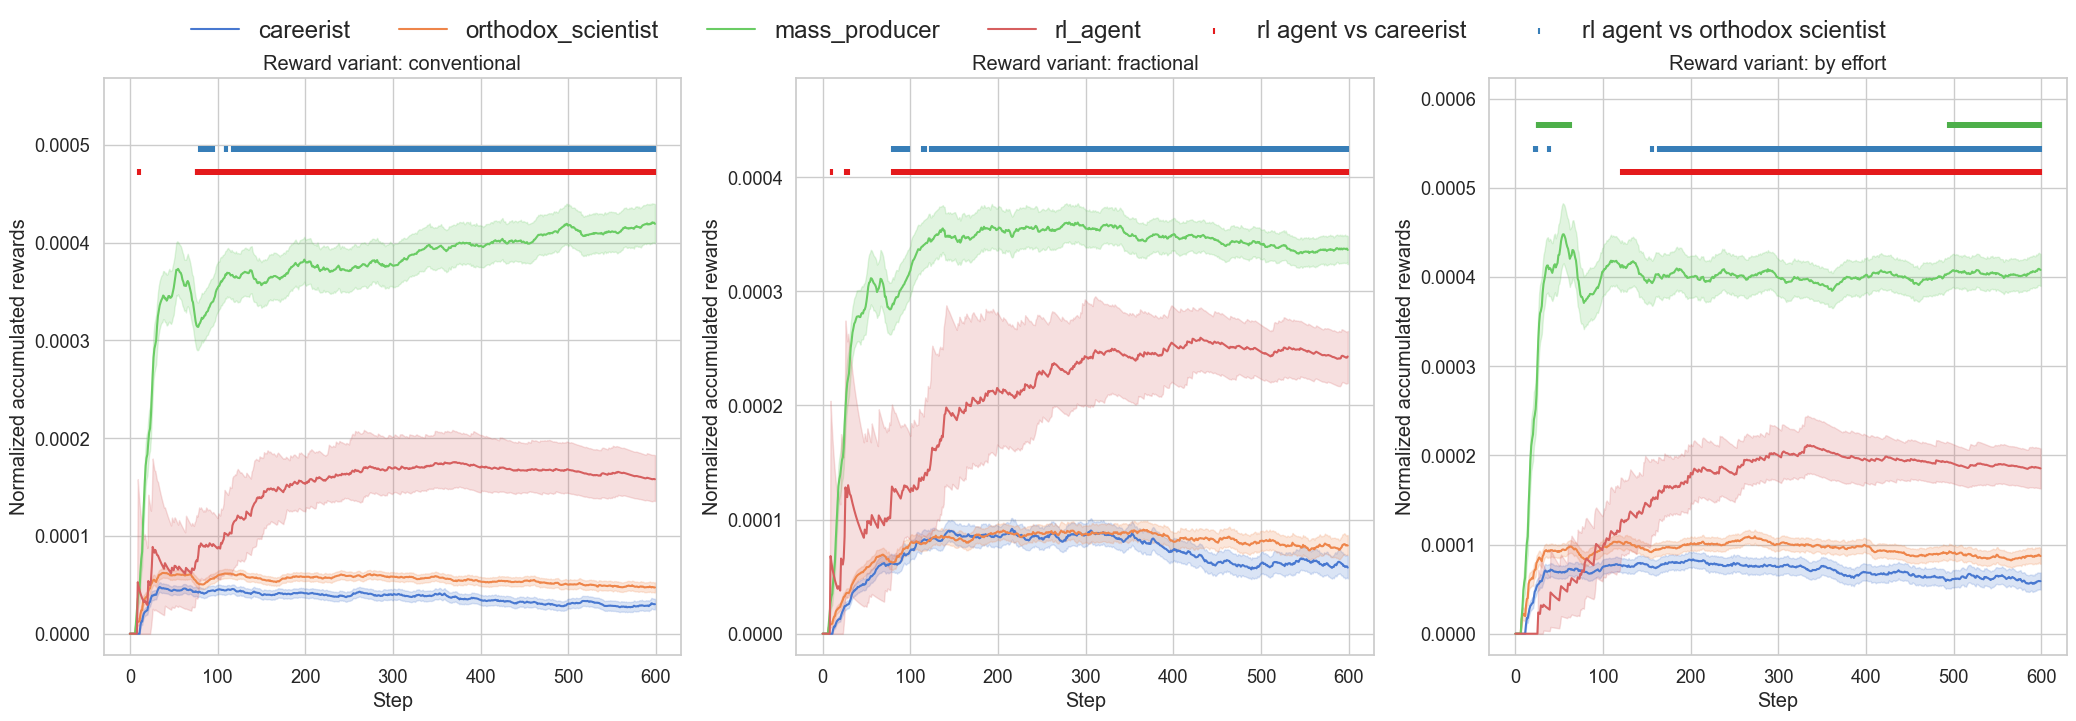

In [40]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# =========================================================
# CONFIG
# =========================================================

variants = {
    "multiply": "conventional",
    "even": "fractional",
    "by_effort": "by effort"
}

archetypes = [
    "careerist",
    "orthodox_scientist",
    "mass_producer",
    "rl_agent"
]

baseline_arch = "rl_agent"
comparison_archetypes = [
    "careerist",
    "orthodox_scientist",
    "mass_producer"
]

time_steps = list(range(600))

# RL agent vs each archetype
pairs = [(baseline_arch, arch) for arch in comparison_archetypes]
pair_colors = {
    ("rl_agent", "careerist"): "#e41a1c",
    ("rl_agent", "orthodox_scientist"): "#377eb8",
    ("rl_agent", "mass_producer"): "#4daf4a"
}

USE_AGE_NORMALIZATION = True
ALPHA = 0.05
FDR_METHOD = "fdr_bh"
N_BOOT = 2000
CI_MODE = "ci"   # "ci" or "se"


# =========================================================
# LOAD DATA
# =========================================================

dfs = {}

for v in variants:
    heuristic_path = f"results/reward_trajectories_{v if v != 'even' else 'evenly'}.parquet"
    rl_path = f"results/rl_trajectories_{v if v != 'even' else 'evenly'}.parquet"

    # Heuristic trajectories
    df_h = pd.read_parquet(heuristic_path)

    # RL trajectories: only keep rl_agent
    df_rl_all = pd.read_parquet(rl_path)
    df_rl_agent = df_rl_all[df_rl_all["archetype"] == "rl_agent"].copy()

    # Merge
    dfs[v] = pd.concat([df_h, df_rl_agent], ignore_index=True)


# =========================================================
# HELPER FUNCTIONS
# =========================================================

def get_variant_global_max(df_variant, reward_col="accumulated_rewards"):
    """
    One shared normalization constant per reward variant across all archetypes.
    This keeps comparisons between rl_agent and archetypes fair within a variant.
    """
    if df_variant.empty:
        return np.nan
    return df_variant[reward_col].max()


def prepare_plot_data_for_variant(df_variant, variant_label):
    """
    Build plotting dataframe for one reward variant across all archetypes.
    Applies one shared normalization constant within the variant.
    """
    plot_df = df_variant.copy()

    if plot_df.empty:
        return pd.DataFrame()

    global_max = get_variant_global_max(plot_df)

    if pd.notna(global_max) and global_max > 0:
        plot_df["accumulated_rewards"] = plot_df["accumulated_rewards"] / global_max

    if USE_AGE_NORMALIZATION:
        if "age" not in plot_df.columns:
            raise KeyError(f"'age' column missing in variant '{variant_label}'.")
        plot_df["accumulated_rewards"] = plot_df["accumulated_rewards"] / (plot_df["age"] + 1)

    return plot_df


def run_rl_vs_archetype_stats(plot_df, variant_name):
    """
    Compare RL agent against each fixed archetype for one reward variant.
    Performs Mann-Whitney U test at each time step, then FDR correction.
    """
    pairwise_results = {}

    print(f"\n{'=' * 80}")
    print(f"Reward variant: {variant_name}")
    print(f"{'=' * 80}")

    for rl_arch, other_arch in pairs:
        raw_p_values = []
        n_valid_tests = 0

        df_rl = plot_df[plot_df["archetype"] == rl_arch]
        df_other = plot_df[plot_df["archetype"] == other_arch]

        for t in time_steps:
            d1 = df_rl.loc[df_rl["step"] == t, "accumulated_rewards"].dropna().values
            d2 = df_other.loc[df_other["step"] == t, "accumulated_rewards"].dropna().values

            # Need at least 2 samples per group
            if len(d1) < 2 or len(d2) < 2:
                raw_p_values.append(1.0)
                continue

            # If both groups are identical constants, no difference
            if (
                np.all(d1 == d1[0]) and
                np.all(d2 == d2[0]) and
                d1[0] == d2[0]
            ):
                raw_p_values.append(1.0)
                continue

            try:
                _, p = stats.mannwhitneyu(d1, d2, alternative="two-sided")
                raw_p_values.append(p)
                n_valid_tests += 1
            except ValueError:
                raw_p_values.append(1.0)

        reject, pvals_corrected, _, _ = multipletests(
            raw_p_values,
            alpha=ALPHA,
            method=FDR_METHOD
        )

        label = f"rl agent vs {other_arch.replace('_', ' ')}"
        pairwise_results[label] = {
            "reject": reject,
            "pvals_corrected": pvals_corrected,
            "raw_p_values": np.array(raw_p_values),
            "pair": (rl_arch, other_arch),
            "color": pair_colors[(rl_arch, other_arch)],
            "n_valid_tests": n_valid_tests
        }

    for label, result in pairwise_results.items():
        proportion_sig = np.mean(result["reject"])
        min_p_corr = np.min(result["pvals_corrected"])
        median_p_corr = np.median(result["pvals_corrected"])

        print(
            f"{label:<38} | "
            f"sig. proportion: {proportion_sig:>6.3f} | "
            f"min p(FDR): {min_p_corr:>8.5f} | "
            f"median p(FDR): {median_p_corr:>8.5f} | "
            f"valid tests: {result['n_valid_tests']:>3d}/{len(time_steps)}"
        )

    return pairwise_results


def add_significance_bars(ax, pairwise_results):
    """
    Add significance markers above the plot.
    """
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min

    if y_range == 0:
        y_range = 1e-6

    current_height = y_max + (y_range * 0.02)
    step_height = y_range * 0.05

    for label, result in pairwise_results.items():
        is_sig = result["reject"]
        sig_steps = np.array(time_steps)[is_sig]

        if len(sig_steps) > 0:
            ax.scatter(
                sig_steps,
                [current_height] * len(sig_steps),
                marker="|",
                s=20,
                color=result["color"],
                label=label
            )

        current_height += step_height

    ax.set_ylim(y_min, current_height + step_height)


def prettify_arch_name(name):
    return name.replace("_", " ")


# =========================================================
# PLOTTING
# =========================================================

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharey=False)

if len(variants) == 1:
    axes = [axes]

for idx, v in enumerate(variants):
    ax = axes[idx]
    variant_label = variants[v]

    print(f"\nProcessing reward variant: {variant_label} ...")

    df_variant = dfs[v].copy()
    plot_df = prepare_plot_data_for_variant(df_variant, variant_label)

    # Keep only archetypes of interest
    plot_df = plot_df[plot_df["archetype"].isin(archetypes)].copy()

    if plot_df.empty:
        ax.set_title(f"{variant_label} (no data)")
        ax.text(0.5, 0.5, "No data available", ha="center", va="center", transform=ax.transAxes)
        continue

    # Plot all archetypes for this reward variant
    sns.lineplot(
        data=plot_df,
        x="step",
        y="accumulated_rewards",
        hue="archetype",
        hue_order=archetypes,
        ax=ax,
        errorbar=CI_MODE,
        n_boot=N_BOOT,
        seed=10
    )

    # Statistics: rl_agent vs the 3 archetypes
    pairwise_results = run_rl_vs_archetype_stats(plot_df, variant_label)

    # Significance markers
    add_significance_bars(ax, pairwise_results)

    # Styling
    ax.set_title(f"Reward variant: {variant_label}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Normalized accumulated rewards")

    # Remove local legend
    leg = ax.get_legend()
    if leg:
        leg.remove()


# =========================================================
# GLOBAL LEGEND
# =========================================================

# Build legend manually from first axis
handles, labels = axes[0].get_legend_handles_labels()

# Deduplicate while preserving order
seen = set()
unique_handles = []
unique_labels = []

for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l)
        unique_handles.append(h)
        unique_labels.append(l)

fig.legend(
    unique_handles,
    unique_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=max(1, len(unique_labels)),
    fontsize="large",
    frameon=False
)

plt.tight_layout()
plt.show()